# **Kernelized Support Vector Machines**

In [2]:
!pip install mglearn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 7.1 MB/s eta 0:00:00


**Part 1. Explore Kernelized SVMs**

**1.Linear models and nonlinear features**

Two-class classification dataset in which classes are not linearly separable


Use LinearSVC to nonlinear data

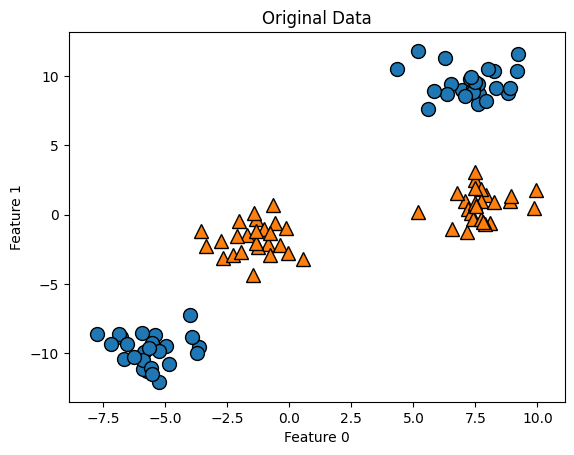

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVC, SVC
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split, GridSearchCV
from mpl_toolkits.mplot3d import Axes3D
import mglearn  # This is often used in textbook examples for visualization

# Generate a synthetic two-dimensional dataset
X, y = make_blobs(centers=4, random_state=8)
y = y % 2  # Convert to binary to simulate nonlinearity

# Visualize the original dataset
mglearn.discrete_scatter(X[:, 0], X[:, 1], y)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.title("Original Data")
plt.show()


A linear model for classification can only separate points using a line, and will not be
able to do a very good job on this dataset

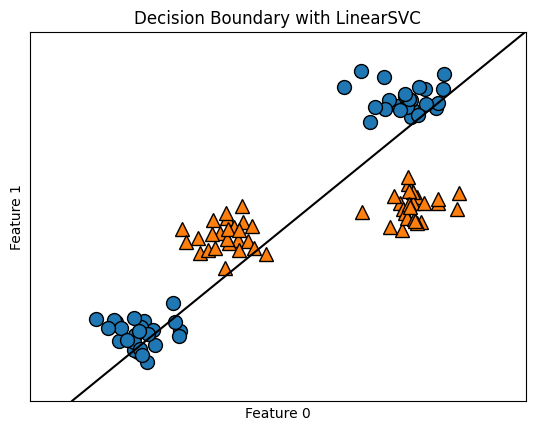

In [5]:
# Fitting LinearSVC to non-linear data
linear_svm = LinearSVC().fit(X, y)

# Plot the decision boundary
mglearn.plots.plot_2d_separator(linear_svm, X, fill=False)
mglearn.discrete_scatter(X[:, 0], X[:, 1], y)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.title("Decision Boundary with LinearSVC")
plt.show()
#Decision boundary found by a linear SVM

Now let’s expand the set of input features, say by also adding feature1 ** 2, the
square of the second feature, as a new feature. Instead of representing each data point
as a two-dimensional point, (feature0, feature1), we now represent it as a threedimensional point, (feature0, feature1, feature1 ** 2).
10 This new representa‐
tion is illustrated in a three-dimensional scatter plot

Expansion of the dataset shown below, created by adding a third
feature derived from feature1

**2. Fit a linear model to the augmented data.**

Visualize the decision boundary found by a linear SVM on the expanded 3-d dataset

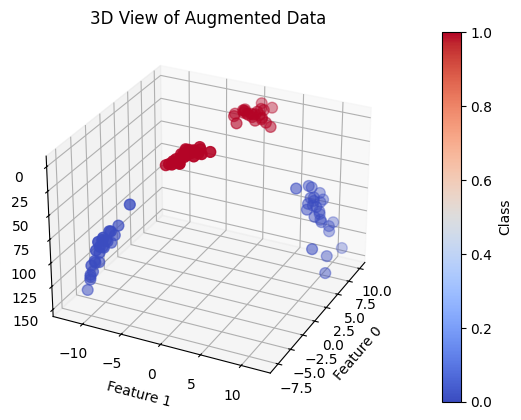

In [90]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import make_blobs

# Generate synthetic data
X, y = make_blobs(centers=4, random_state=8)
y = y % 2  # Reduce to a binary classification problem for simplicity

# Add the squared second feature
X_new = np.hstack([X, X[:, 1:] ** 2])

# Create a 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_new[:, 0], X_new[:, 1], X_new[:, 2], c=y, cmap=plt.cm.coolwarm, s=60)

# Setting the labels for each axis
ax.set_xlabel("Feature 0")
ax.set_ylabel("Feature 1")
ax.set_zlabel("Feature1^2")

# Adjust the view angle
ax.view_init(elev=-152, azim=-26)  # You can modify these angles to get the best view

plt.title("3D View of Augmented Data")

# Add a color bar
cbar = plt.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label('Class')

plt.show()


Decision boundary found by a linear SVM on the expanded threedimensional dataset

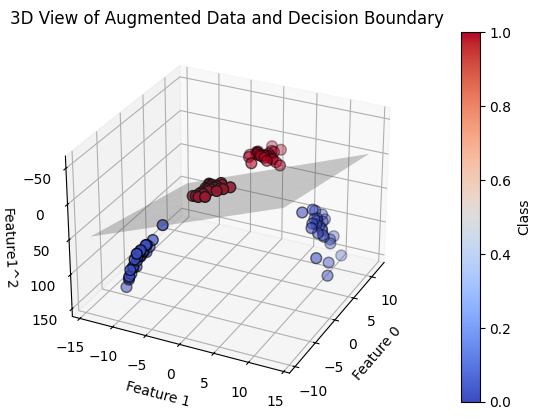

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import make_blobs
from sklearn.svm import LinearSVC

# Generate synthetic data
X, y = make_blobs(centers=4, random_state=8)
y = y % 2  # Reduce to a binary classification problem for simplicity

# Add the squared second feature
X_new = np.hstack([X, X[:, 1:] ** 2])

# Fit LinearSVC on the augmented data
linear_svm_3d = LinearSVC().fit(X_new, y)
coef, intercept = linear_svm_3d.coef_.ravel(), linear_svm_3d.intercept_

# Create a 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')


# Define the grid for the decision boundary
xx, yy = np.meshgrid(np.linspace(X_new[:, 0].min() - 2, X_new[:, 0].max() + 2, 50),
                     np.linspace(X_new[:, 1].min() - 2, X_new[:, 1].max() + 2, 50))
# Compute z values (decision boundary)
zz = (coef[0] * xx + coef[1] * yy + intercept) / -coef[2]
# Plot the decision boundary surface
ax.plot_surface(xx, yy, zz, rstride=8, cstride=8, alpha=0.3, color='grey')

# Scatter plot of the data points
scatter = ax.scatter(X_new[:, 0], X_new[:, 1], X_new[:, 2], c=y, cmap=plt.cm.coolwarm, s=60, edgecolor='k')

# Add a color bar to indicate classes
cbar = plt.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label('Class')

# Setting the labels for each axis
ax.set_xlabel("Feature 0")
ax.set_ylabel("Feature 1")
ax.set_zlabel("Feature1^2")

# Adjust the view angle
ax.view_init(elev=-152, azim=-26)  # Set the viewing angles

plt.title("3D View of Augmented Data and Decision Boundary")
plt.show()


Decision boundary and support vectors found by an SVM with RBF kernel

Text(0, 0.5, 'Feature 1')

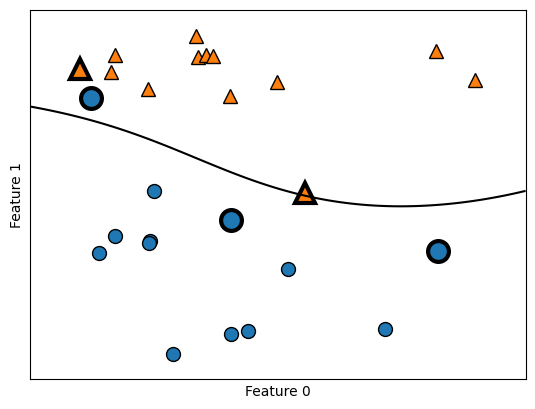

In [12]:
from sklearn.svm import SVC
X, y = mglearn.tools.make_handcrafted_dataset()
svm = SVC(kernel='rbf', C=10, gamma=0.1).fit(X, y)
mglearn.plots.plot_2d_separator(svm, X, eps=.5)
mglearn.discrete_scatter(X[:, 0], X[:, 1], y)
# plot support vectors
sv = svm.support_vectors_
# class labels of support vectors are given by the sign of the dual coefficients
sv_labels = svm.dual_coef_.ravel() > 0
mglearn.discrete_scatter(sv[:, 0], sv[:, 1], sv_labels, s=15, markeredgewidth=3)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

**3. Tuning SVM parameters**

>Fine-tune hyperparameters C and gamma



Gamma Parameter:
Gamma relates to the Gaussian kernel's width in the model, acting like an inverse; a smaller gamma means a wider kernel.
The effect of gamma is on how far a single training example's influence can reach. A smaller gamma results in a broader reach, affecting more of the surrounding points, while a higher gamma limits the influence to closer points.


C Parameter:
C is a regularization parameter, similar to those used in linear models.
It helps control how much each data point should influence the final decision boundary. A lower C means each point has less influence, making the model less likely to overfit to the training data. Conversely, a higher C allows individual points to have more impact, potentially capturing more complex patterns but also risking overfitting.

Decision boundaries and support vectors for different settings of the param‐
eters C and gamma


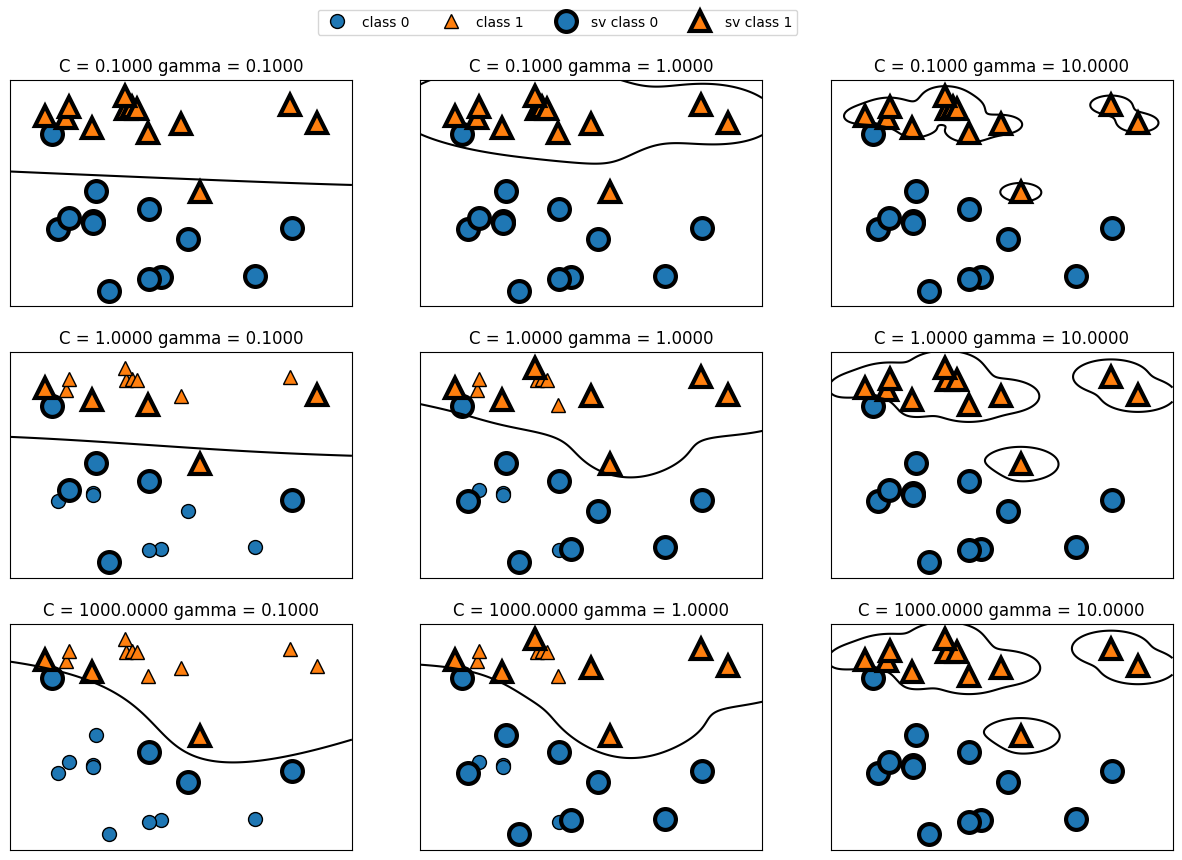

In [13]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, C in zip(axes, [-1, 0, 3]):
  for a, gamma in zip(ax, range(-1, 2)):
    mglearn.plots.plot_svm(log_C=C, log_gamma=gamma, ax=a)
    axes[0, 0].legend(["class 0", "class 1", "sv class 0", "sv class 1"],ncol=4, loc=(.9, 1.2))

Gamma Parameter Adjustment:

As you move from left to right in a visual display, the gamma value increases from 0.1 to 10.
A small gamma results in a large Gaussian kernel radius, meaning more points are considered close, creating smooth decision boundaries.
A larger gamma focuses more on individual points, leading to complex decision boundaries that adapt closely around data points.
Effect of Gamma on Model Complexity:
Lower gamma values produce slow-varying decision boundaries, resulting in a simpler model.
Higher gamma values allow for more detailed boundaries, resulting in a more complex model.

C Parameter Adjustment:

From top to bottom, the C parameter increases from 0.1 to 1000.
A smaller C restricts the model significantly, limiting the influence of individual data points. This is evident in nearly linear boundaries with misclassified points having minimal impact.
Impact of Increasing C:

Increasing C allows individual points to exert more influence on the model.
This adjustment makes the decision boundary more flexible, bending to correctly classify points that were previously misclassified.

**Part 2. Build an SVM model to classify the Breast Cancer Data**


**1.Preprocessing data for SVMs**

Use MinMaxScaler method

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.datasets import load_breast_cancer

# Load the dataset
cancer = load_breast_cancer()

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, random_state=0)

# Initialize and train the SVC model
svc = SVC()
svc.fit(X_train, y_train)

# Print accuracy on the training and test set
print("Accuracy on training set: {:.2f}".format(svc.score(X_train, y_train)))
print("Accuracy on test set: {:.2f}".format(svc.score(X_test, y_test)))


Accuracy on training set: 0.90
Accuracy on test set: 0.94


Let’s look at the mini‐
mum and maximum values for each feature, plotted in log-space

Text(0, 0.5, 'Feature magnitude')

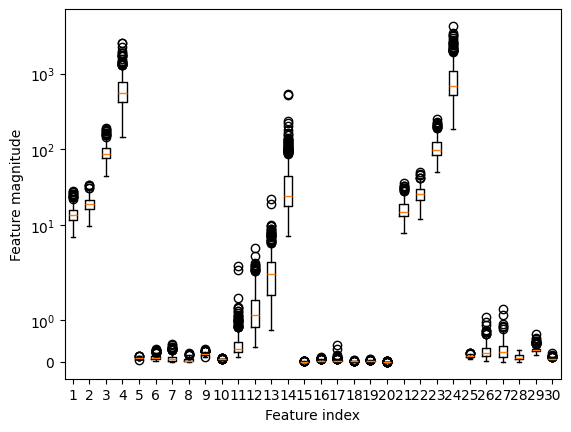

In [18]:
plt.boxplot(X_train)
plt.yscale("symlog")
plt.xlabel("Feature index")
plt.ylabel("Feature magnitude")
#Feature ranges for the Breast Cancer dataset (note that the y axis has a log‐arithmic scale)

From this plot we can determine that features in the Breast Cancer dataset are of
completely different orders of magnitude. This can be somewhat of a problem for
other models (like linear models), but it has devastating effects for the kernel SVM.

**Preprocessing data for SVMs**

One way to resolve this problem is by rescaling each feature so that they are all
approximately on the same scale. A common rescaling method for kernel SVMs is to
scale the data such that all features are between 0 and 1. We will see how to do this
using the MinMaxScaler preprocessing method

In [19]:
# compute the minimum value per feature on the training set
min_on_training = X_train.min(axis=0)
# compute the range of each feature (max - min) on the training set
range_on_training = (X_train - min_on_training).max(axis=0)
# subtract the min, and divide by range
# afterward, min=0 and max=1 for each feature
X_train_scaled = (X_train - min_on_training) / range_on_training
print("Minimum for each feature\n{}".format(X_train_scaled.min(axis=0)))
print("Maximum for each feature\n {}".format(X_train_scaled.max(axis=0)))


Minimum for each feature
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]
Maximum for each feature
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]


**2. Fit a SVM model with SVC()**

In [20]:
# use THE SAME transformation on the test set,
# using min and range of the training set (see Chapter 3 for details)
X_test_scaled = (X_test - min_on_training) / range_on_training
svc = SVC()
svc.fit(X_train_scaled, y_train)
print("Accuracy on training set: {:.3f}".format(
 svc.score(X_train_scaled, y_train)))
print("Accuracy on test set: {:.3f}".format(svc.score(X_test_scaled, y_test)))

Accuracy on training set: 0.984
Accuracy on test set: 0.972


Scaling the data made a huge difference! Now we are actually in an underfitting
regime, where training and test set performance are quite similar but less close to
100% accuracy. From here, we can try increasing either C or gamma to fit a more com‐
plex model.

**3. Fine-tune C and gamma (2 extra credits)**



In [23]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {'C': [0.1, 1, 10, 100], 'gamma': [0.01, 0.1, 1, 10], 'kernel': ['rbf']}

# Create a GridSearchCV object
grid_search = GridSearchCV(SVC(), param_grid, cv=5)

# Fit GridSearchCV
grid_search.fit(X_train_scaled, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score: {:.2f}".format(grid_search.best_score_))

Best parameters: {'C': 1, 'gamma': 1, 'kernel': 'rbf'}
Best cross-validation score: 0.98


In [24]:
svc = SVC(C=1000)
svc.fit(X_train_scaled, y_train)
print("Accuracy on training set: {:.3f}".format(
 svc.score(X_train_scaled, y_train)))
print("Accuracy on test set: {:.3f}".format(svc.score(X_test_scaled, y_test)))

Accuracy on training set: 1.000
Accuracy on test set: 0.958


**Parameters in SVMs:**

Regularization Parameter (C): Controls the influence of each individual data point. A higher C allows individual outliers to influence the model more, whereas a lower C creates a smoother decision boundary by emphasizing the overall error margin.

Kernel Choice: The decision of which kernel to use (like linear, polynomial, RBF, etc.) affects how the model performs. Different kernels can capture different types of patterns in data.

Kernel-Specific Parameters: For instance, the RBF kernel includes the gamma parameter, which influences the range of influence for each data point. Smaller gamma values mean a wider range, affecting more points broadly.